
# Pattern Search on the Branin–Hoo Function

This notebook illustrates the **pattern search** method on the Branin–Hoo function. The implementation follows the standard direct-search description used in Nocedal & Wright: at each iteration, the method tests points from a positive spanning set around the current iterate using a step length $\Delta_k$. If an improving point is found, the iterate is updated and the step is typically maintained or expanded; otherwise, the step length is contracted.

At the end, we compare **pattern search** with **coordinate search**, starting from the **same initial point** $\mathbf{x}_0$.

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

plt.rcParams.update({
    "figure.figsize": (9, 7.0),
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

# Use LaTeX for plot text if available; otherwise fall back gracefully.
try:
    rcParams["text.usetex"] = True
except Exception:
    rcParams["text.usetex"] = False

rcParams["font.size"] = 12
rcParams["axes.labelsize"] = 12
rcParams["axes.titlesize"] = 13

np.set_printoptions(precision=6, suppress=True)



## The Branin–Hoo function

We use the standard two-dimensional Branin–Hoo test problem:
$
f(x_1,x_2)=
a\left(x_2-bx_1^2+cx_1-r\right)^2+s(1-t)\cos(x_1)+s,
$
with constants
$
a=1,\quad
b=\frac{5.1}{4\pi^2},\quad
c=\frac{5}{\pi},\quad
r=6,\quad
s=10,\quad
t=\frac{1}{8\pi}.
$

The usual box domain is
$
x_1\in[-5,10], \qquad x_2\in[0,15].
$


In [16]:

def branin(x):
    x = np.asarray(x, dtype=float)
    x1, x2 = x[..., 0], x[..., 1]
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

bounds = np.array([[-5.0, 10.0],
                   [ 0.0, 15.0]])

def project_to_bounds(x, bounds=bounds):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], bounds[0, 0], bounds[0, 1])
    x[1] = np.clip(x[1], bounds[1, 0], bounds[1, 1])
    return x


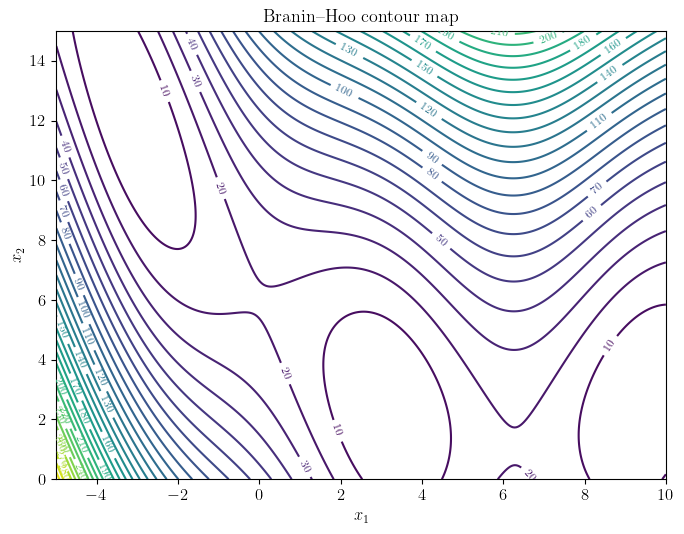

In [17]:

# Build a contour grid
x1 = np.linspace(bounds[0,0], bounds[0,1], 400)
x2 = np.linspace(bounds[1,0], bounds[1,1], 400)
X1, X2 = np.meshgrid(x1, x2)
F = branin(np.stack([X1, X2], axis=-1))

plt.figure(figsize=(7, 5.5))
cs = plt.contour(X1, X2, F, levels=30)
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Branin--Hoo contour map")
plt.tight_layout()
plt.show()



## Coordinate search

We first define a simple coordinate search method for reference. At each iteration, it tests the axis-aligned directions
$
\mathcal{D}_{\mathrm{coord}}=\{\pm e_1,\pm e_2\},
$
using a current step size $\Delta_k$. If a successful move is found, the iterate is updated; otherwise the step size is reduced.

This gives us a baseline that is easy to explain in class.


In [33]:

def coordinate_search(
    f,
    x0,
    delta0=1.0,
    delta_min=1e-3,
    shrink=0.5,
    max_iters=100,
    bounds=bounds
):
    directions = [
        np.array([1.0, 0.0]),
        np.array([-1.0, 0.0]),
        np.array([0.0, 1.0]),
        np.array([0.0, -1.0]),
    ]

    x = project_to_bounds(x0, bounds)
    fx = f(x)
    delta = float(delta0)

    history = [{
        "iter": 0,
        "x": x.copy(),
        "f": float(fx),
        "delta": float(delta),
        "success": None,
        "accepted_direction": None,
        "trials": []
    }]

    k = 0
    while delta > delta_min and k < max_iters:
        improved = False
        accepted_direction = None
        trials = []

        for d in directions:
            x_trial = project_to_bounds(x + delta * d, bounds)
            f_trial = f(x_trial)
            trials.append({
                "direction": d.copy(),
                "x_trial": x_trial.copy(),
                "f_trial": float(f_trial)
            })
            if f_trial < fx:
                x = x_trial
                fx = f_trial
                improved = True
                accepted_direction = d.copy()
                break

        if not improved:
            delta *= shrink

        k += 1
        history.append({
            "iter": k,
            "x": x.copy(),
            "f": float(fx),
            "delta": float(delta),
            "success": improved,
            "accepted_direction": accepted_direction,
            "trials": trials
        })

    return history



## Pattern search

For pattern search, we keep the same local polling directions
$
\{\pm e_1,\pm e_2\},
$
but after a successful exploratory move we also try a **pattern move** in the same net direction as the latest successful displacement.

In other words:
1. perform an exploratory search around the current point,
2. if successful, obtain a new point $x^{\mathrm{exp}}$,
3. then try a pattern step
   $
   x^{\mathrm{pat}} = x^{\mathrm{exp}} + \left(x^{\mathrm{exp}} - x^{(k)}\right),
   $
4. accept the pattern point if it improves further.

This often accelerates progress when the objective decreases consistently along a trend.


In [34]:

def pattern_search(
    f,
    x0,
    delta0=1.0,
    delta_min=1e-3,
    shrink=0.5,
    max_iters=100,
    bounds=bounds
):
    directions = [
        np.array([1.0, 0.0]),
        np.array([-1.0, 0.0]),
        np.array([0.0, 1.0]),
        np.array([0.0, -1.0]),
    ]

    x = project_to_bounds(x0, bounds)
    fx = f(x)
    delta = float(delta0)

    history = [{
        "iter": 0,
        "x": x.copy(),
        "f": float(fx),
        "delta": float(delta),
        "success": None,
        "accepted_direction": None,
        "exploratory_trials": [],
        "pattern_trial": None,
        "accepted_step_type": None
    }]

    k = 0
    while delta > delta_min and k < max_iters:
        exploratory_trials = []
        improved = False
        accepted_direction = None

        x_base = x.copy()
        f_base = fx

        # Exploratory search
        x_exp = x_base.copy()
        f_exp = f_base

        for d in directions:
            x_trial = project_to_bounds(x_base + delta * d, bounds)
            f_trial = f(x_trial)
            exploratory_trials.append({
                "direction": d.copy(),
                "x_trial": x_trial.copy(),
                "f_trial": float(f_trial)
            })
            if f_trial < f_exp:
                x_exp = x_trial
                f_exp = f_trial
                improved = True
                accepted_direction = d.copy()
                break

        pattern_trial = None
        accepted_step_type = None

        if improved:
            # Try pattern move: x_pat = x_exp + (x_exp - x_base)
            x_pat = project_to_bounds(x_exp + (x_exp - x_base), bounds)
            f_pat = f(x_pat)
            pattern_trial = {
                "x_trial": x_pat.copy(),
                "f_trial": float(f_pat)
            }

            if f_pat < f_exp:
                x = x_pat
                fx = f_pat
                accepted_step_type = "pattern"
            else:
                x = x_exp
                fx = f_exp
                accepted_step_type = "exploratory"
        else:
            delta *= shrink

        k += 1
        history.append({
            "iter": k,
            "x": x.copy(),
            "f": float(fx),
            "delta": float(delta),
            "success": improved,
            "accepted_direction": accepted_direction,
            "exploratory_trials": exploratory_trials,
            "pattern_trial": pattern_trial,
            "accepted_step_type": accepted_step_type
        })

    return history



## Choose a common initial point

To make the comparison meaningful, both methods start from the same
$
\mathbf{x}_0.
$

You can change $\mathbf{x}_0$ below and rerun the notebook.


In [35]:

x0 = np.array([6.0, 12.0])
delta0 = 1.0
delta_min = 1e-3
max_iters = 60

cs_hist = coordinate_search(
    branin, x0,
    delta0=delta0,
    delta_min=delta_min,
    max_iters=max_iters,
    bounds=bounds
)

ps_hist = pattern_search(
    branin, x0,
    delta0=delta0,
    delta_min=delta_min,
    max_iters=max_iters,
    bounds=bounds
)

print("Initial point x0 =", x0)
print("Initial function value =", branin(x0))
print()
print("Coordinate search final point:", cs_hist[-1]["x"])
print("Coordinate search final value:", cs_hist[-1]["f"])
print("Coordinate search iterations:", len(cs_hist)-1)
print()
print("Pattern search final point:", ps_hist[-1]["x"])
print("Pattern search final value:", ps_hist[-1]["f"])
print("Pattern search iterations:", len(ps_hist)-1)


Initial point x0 = [ 6. 12.]
Initial function value = 138.00032784720685

Coordinate search final point: [9.425781 2.476562]
Coordinate search final value: 0.39789270318346226
Coordinate search iterations: 36

Pattern search final point: [9.425781 2.476562]
Pattern search final value: 0.39789270318346226
Pattern search iterations: 28



## Inspect the first few iterations

The tables below make it easier to explain the mechanics in class.


In [36]:

def print_coordinate_iterations(history, num_iters=5):
    for rec in history[1:num_iters+1]:
        print(f"Iteration {rec['iter']}")
        print(f"  x_k       = {rec['x']}")
        print(f"  f(x_k)    = {rec['f']:.6f}")
        print(f"  delta_k   = {rec['delta']:.6f}")
        print(f"  success   = {rec['success']}")
        print(f"  accepted direction = {rec['accepted_direction']}")
        print("  trials:")
        for t in rec["trials"]:
            print(f"    dir={t['direction']}, x_trial={t['x_trial']}, f_trial={t['f_trial']:.6f}")
        print()

def print_pattern_iterations(history, num_iters=5):
    for rec in history[1:num_iters+1]:
        print(f"Iteration {rec['iter']}")
        print(f"  x_k       = {rec['x']}")
        print(f"  f(x_k)    = {rec['f']:.6f}")
        print(f"  delta_k   = {rec['delta']:.6f}")
        print(f"  success   = {rec['success']}")
        print(f"  accepted direction = {rec['accepted_direction']}")
        print(f"  accepted step type = {rec['accepted_step_type']}")
        print("  exploratory trials:")
        for t in rec["exploratory_trials"]:
            print(f"    dir={t['direction']}, x_trial={t['x_trial']}, f_trial={t['f_trial']:.6f}")
        if rec["pattern_trial"] is not None:
            pt = rec["pattern_trial"]
            print(f"  pattern trial: x_trial={pt['x_trial']}, f_trial={pt['f_trial']:.6f}")
        print()

print("Coordinate search:")
print_coordinate_iterations(cs_hist, num_iters=5)

print("=" * 80)
print("Pattern search:")
print_pattern_iterations(ps_hist, num_iters=5)


Coordinate search:
Iteration 1
  x_k       = [ 7. 12.]
  f(x_k)    = 134.112561
  delta_k   = 1.000000
  success   = True
  accepted direction = [1. 0.]
  trials:
    dir=[1. 0.], x_trial=[ 7. 12.], f_trial=134.112561

Iteration 2
  x_k       = [ 8. 12.]
  f(x_k)    = 118.110470
  delta_k   = 1.000000
  success   = True
  accepted direction = [1. 0.]
  trials:
    dir=[1. 0.], x_trial=[ 8. 12.], f_trial=118.110470

Iteration 3
  x_k       = [ 9. 12.]
  f(x_k)    = 98.470817
  delta_k   = 1.000000
  success   = True
  accepted direction = [1. 0.]
  trials:
    dir=[1. 0.], x_trial=[ 9. 12.], f_trial=98.470817

Iteration 4
  x_k       = [10. 12.]
  f(x_k)    = 82.889931
  delta_k   = 1.000000
  success   = True
  accepted direction = [1. 0.]
  trials:
    dir=[1. 0.], x_trial=[10. 12.], f_trial=82.889931

Iteration 5
  x_k       = [10. 11.]
  f(x_k)    = 65.895844
  delta_k   = 1.000000
  success   = True
  accepted direction = [ 0. -1.]
  trials:
    dir=[1. 0.], x_trial=[10. 12.], f_tr


## Plot the search paths

We now overlay both trajectories on the Branin–Hoo contours.


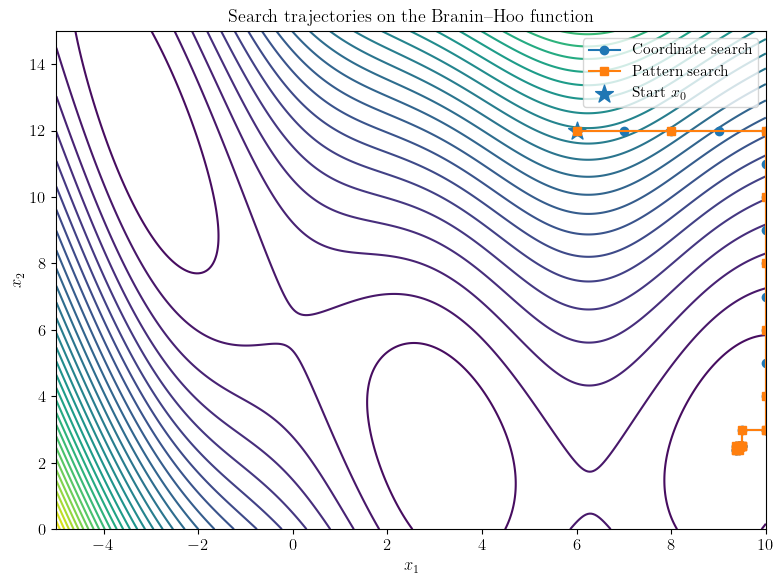

In [38]:

def extract_path(history):
    return np.array([rec["x"] for rec in history], dtype=float)

cs_path = extract_path(cs_hist)
ps_path = extract_path(ps_hist)

plt.figure(figsize=(8, 6))
plt.contour(X1, X2, F, levels=35)
plt.plot(cs_path[:, 0], cs_path[:, 1], marker="o", label="Coordinate search")
plt.plot(ps_path[:, 0], ps_path[:, 1], marker="s", label="Pattern search")
plt.scatter([x0[0]], [x0[1]], marker="*", s=180, label=r"Start $x_0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Search trajectories on the Branin--Hoo function")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_cs_v_ps.png")



## Objective value versus iteration


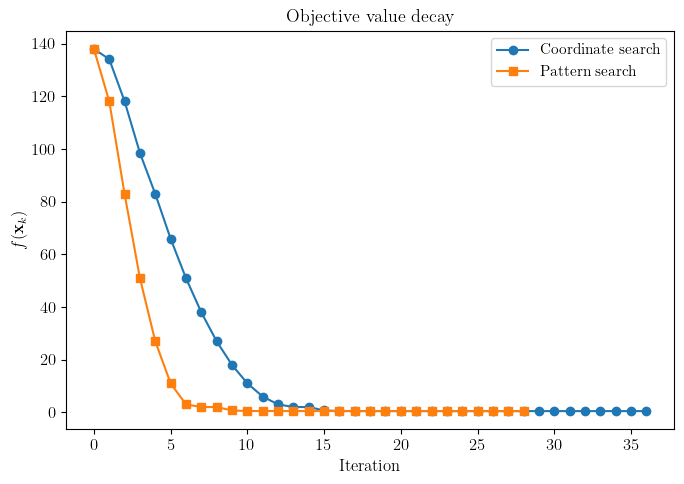

In [41]:

cs_f = np.array([rec["f"] for rec in cs_hist], dtype=float)
ps_f = np.array([rec["f"] for rec in ps_hist], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_f)), cs_f, marker="o", label="Coordinate search")
plt.plot(np.arange(len(ps_f)), ps_f, marker="s", label="Pattern search")
plt.xlabel("Iteration")
plt.ylabel(r"$f(\mathbf{x}_{k})$")
plt.title(r"Objective value decay")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_ps_v_cs_fk.png")



## Step size versus iteration


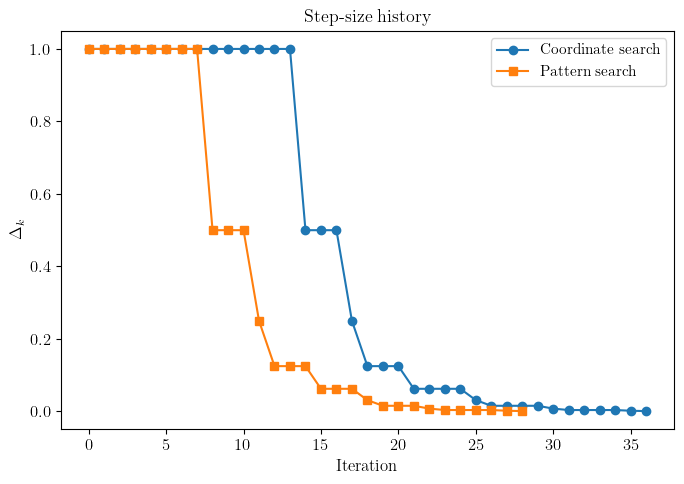

In [42]:

cs_delta = np.array([rec["delta"] for rec in cs_hist], dtype=float)
ps_delta = np.array([rec["delta"] for rec in ps_hist], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_delta)), cs_delta, marker="o", label="Coordinate search")
plt.plot(np.arange(len(ps_delta)), ps_delta, marker="s", label="Pattern search")
plt.xlabel("Iteration")
plt.ylabel(r"$\Delta_k$")
plt.title(r"Step-size history")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_ps_v_cs_deltak.png")



## Quantitative comparison

Below is a simple comparison using the same starting point and the same initial step size.


In [26]:
def summarize(history, name):
    xs = np.array([rec["x"] for rec in history], dtype=float)
    fs = np.array([rec["f"] for rec in history], dtype=float)
    step_types = []
    exploratory_successes = 0
    pattern_successes = 0

    total_trial_evals = 0
    for rec in history[1:]:
        if "trials" in rec:
            total_trial_evals += len(rec["trials"])
        if "exploratory_trials" in rec:
            total_trial_evals += len(rec["exploratory_trials"])
            if rec["success"]:
                exploratory_successes += 1
            if rec.get("accepted_step_type", None) == "pattern":
                pattern_successes += 1
        step_types.append(rec.get("accepted_step_type", None))

    path_length = np.sum(np.linalg.norm(xs[1:] - xs[:-1], axis=1))

    return {
        "method": name,
        "final_x": xs[-1],
        "final_f": fs[-1],
        "iterations": len(history) - 1,
        "path_length": path_length,
        "total_trial_evals": total_trial_evals,
        "pattern_successes": pattern_successes,
        "successful_iterations": int(np.sum(np.diff(fs) < 0.0))
    }

cs_summary = summarize(cs_hist, "Coordinate search")
ps_summary = summarize(ps_hist, "Pattern search")

for summary in [cs_summary, ps_summary]:
    print(summary["method"])
    print("  final_x            =", summary["final_x"])
    print("  final_f            =", summary["final_f"])
    print("  iterations         =", summary["iterations"])
    print("  path_length        =", summary["path_length"])
    print("  total_trial_evals  =", summary["total_trial_evals"])
    print("  successful_iters   =", summary["successful_iterations"])
    print("  pattern_successes  =", summary["pattern_successes"])
    print()


Coordinate search
  final_x            = [9.425781 2.476562]
  final_f            = 0.39789270318346226
  iterations         = 36
  path_length        = 14.49609375
  total_trial_evals  = 116
  successful_iters   = 26
  pattern_successes  = 0

Pattern search
  final_x            = [9.425781 2.476562]
  final_f            = 0.39789270318346226
  iterations         = 28
  path_length        = 14.49609375
  total_trial_evals  = 91
  successful_iters   = 18
  pattern_successes  = 8



In [43]:
import numpy as np

def positive_basis_pattern_directions(n):
    """
    Construct the positive basis
        p_i     = (1/(2n)) e - e_i,   i = 1,...,n
        p_{n+1} = (1/(2n)) e
    where e is the all-ones vector in R^n.
    """
    e = np.ones(n)
    dirs = []

    for i in range(n):
        e_i = np.zeros(n)
        e_i[i] = 1.0
        p_i = (1.0 / (2.0 * n)) * e - e_i
        dirs.append(p_i)

    p_np1 = (1.0 / (2.0 * n)) * e
    dirs.append(p_np1)

    return dirs

    
def pattern_search_positive_basis(
    f,
    x0,
    delta0=1.0,
    delta_min=1e-3,
    shrink=0.5,
    max_iters=100,
    bounds=None,
):
    """
    Pattern search using the positive basis
        p_i = (1/(2n)) e - e_i,  i=1,...,n,
        p_{n+1} = (1/(2n)) e.
    """
    x = np.asarray(x0, dtype=float).copy()
    n = len(x)

    if bounds is not None:
        x = project_to_bounds(x, bounds)

    fx = float(f(x))
    delta = float(delta0)
    directions = positive_basis_pattern_directions(n)

    history = [{
        "iter": 0,
        "x": x.copy(),
        "f": fx,
        "delta": delta,
        "success": None,
        "accepted_direction": None,
        "trials": []
    }]

    k = 0
    while delta > delta_min and k < max_iters:
        improved = False
        accepted_direction = None
        trials = []

        for p in directions:
            x_trial = x + delta * p
            if bounds is not None:
                x_trial = project_to_bounds(x_trial, bounds)

            f_trial = float(f(x_trial))

            trials.append({
                "direction": p.copy(),
                "x_trial": x_trial.copy(),
                "f_trial": f_trial
            })

            if f_trial < fx:
                x = x_trial
                fx = f_trial
                improved = True
                accepted_direction = p.copy()
                break

        if not improved:
            delta *= shrink

        k += 1
        history.append({
            "iter": k,
            "x": x.copy(),
            "f": fx,
            "delta": delta,
            "success": improved,
            "accepted_direction": accepted_direction,
            "trials": trials
        })

    return history



In [48]:
x0 = np.array([6.0, 12.0])

ps_hist = pattern_search_positive_basis(
    branin,
    x0=x0,
    delta0=1.0,
    delta_min=1e-3,
    shrink=0.5,
    max_iters=60,
    bounds=bounds
)

print("Initial point:", x0)
print("Initial value:", branin(x0))
print("Final point:", ps_hist[-1]["x"])
print("Final value:", ps_hist[-1]["f"])
print("Iterations:", len(ps_hist) - 1)

Initial point: [ 6. 12.]
Initial value: 138.00032784720685
Final point: [-3.134766 12.236328]
Final value: 0.39860711947419425
Iterations: 60


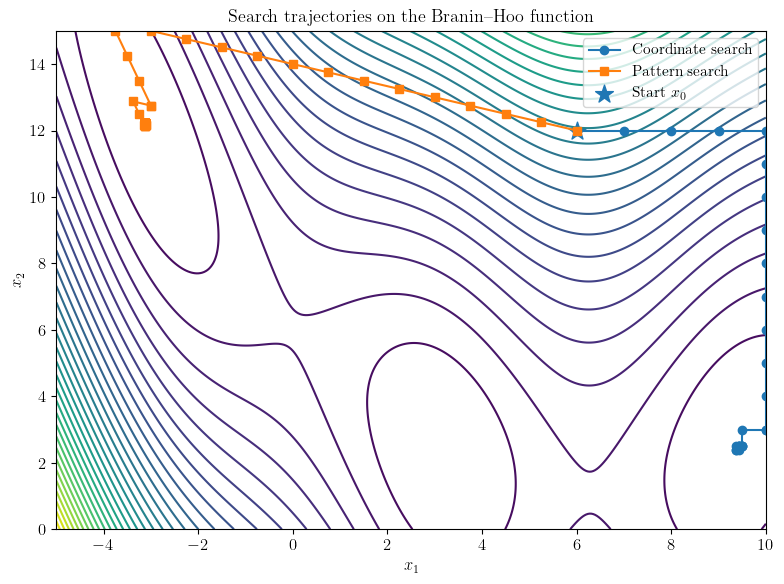

In [49]:

def extract_path(history):
    return np.array([rec["x"] for rec in history], dtype=float)

cs_path = extract_path(cs_hist)
ps_path = extract_path(ps_hist)

plt.figure(figsize=(8, 6))
plt.contour(X1, X2, F, levels=35)
plt.plot(cs_path[:, 0], cs_path[:, 1], marker="o", label="Coordinate search")
plt.plot(ps_path[:, 0], ps_path[:, 1], marker="s", label="Pattern search")
plt.scatter([x0[0]], [x0[1]], marker="*", s=180, label=r"Start $x_0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Search trajectories on the Branin--Hoo function")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_cs_v_ps_2.png")


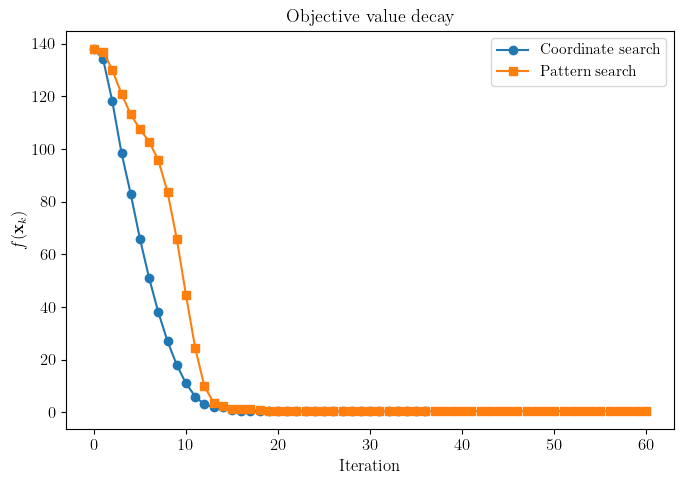

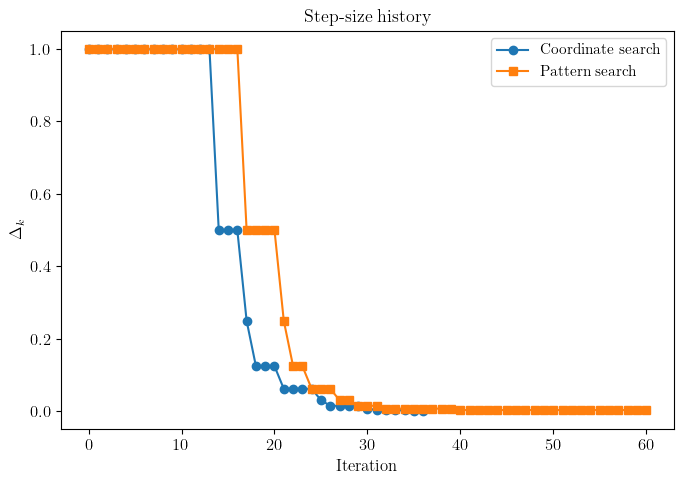

In [51]:

cs_f = np.array([rec["f"] for rec in cs_hist], dtype=float)
ps_f = np.array([rec["f"] for rec in ps_hist], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_f)), cs_f, marker="o", label="Coordinate search")
plt.plot(np.arange(len(ps_f)), ps_f, marker="s", label="Pattern search")
plt.xlabel("Iteration")
plt.ylabel(r"$f(\mathbf{x}_{k})$")
plt.title(r"Objective value decay")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_ps_v_cs_fk_2.png")



cs_delta = np.array([rec["delta"] for rec in cs_hist], dtype=float)
ps_delta = np.array([rec["delta"] for rec in ps_hist], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_delta)), cs_delta, marker="o", label="Coordinate search")
plt.plot(np.arange(len(ps_delta)), ps_delta, marker="s", label="Pattern search")
plt.xlabel("Iteration")
plt.ylabel(r"$\Delta_k$")
plt.title(r"Step-size history")
plt.legend()
plt.tight_layout()
plt.savefig("figures/branin_ps_v_cs_deltak_2.png")



## Discussion

From the same initial point, both methods seek descent without using derivatives. The main difference is this:

- **Coordinate search** only accepts local coordinate moves.
- **Pattern search** first finds a successful exploratory move and then tries to continue in that trend with a larger **pattern move**.

In practical terms, pattern search may reach a good basin faster because it can capitalize on consistent local decrease. Coordinate search is simpler and often easier to explain first, but it may require more conservative progress when the objective favors repeated movement in a similar direction.

Because Branin–Hoo is nonconvex and has multiple minima, the exact behavior depends on the initial point $\mathbf{x}_0$ and step-size settings. It is worth changing $x_0$ and rerunning the notebook to show how both methods can behave differently from different starting locations.



## Suggested classroom exercises

1. Change the starting point $\mathbf{x}_0$ and compare the resulting paths.
2. Change the initial step size $\Delta_0$ and see how sensitive the methods are.
3. Modify the polling order of the directions and observe how a deterministic direct-search method can depend on direction ordering.
4. Add stopping tests based on small function decrease rather than only on $\Delta_k$.
5. Compare the direct-search trajectories with a gradient-based optimizer from SciPy.
